# TabPFN 3.0 für die Etappen-Vorhersage

Dieses Notebook nutzt die in `10-00_Model_Data_Prep.ipynb` erzeugten Modelldaten und trainiert ein TabPFN-Modell für die Frage:

> Mit welcher Wahrscheinlichkeit landet ein Fahrer auf einer Etappe in den Top 10?

Aus diesen Wahrscheinlichkeiten bauen wir anschließend eine stage-weite Vorhersage: pro Etappe werden die Fahrer nach `p_top10_tabpfn` sortiert. Damit passt TabPFN zu unserem Projekt, obwohl das ursprüngliche Problem ein Ranking-Problem ist.

## Was ist TabPFN?

TabPFN steht für **Tabular Prior-Data Fitted Network**. Es ist ein Foundation Model für tabellarische Daten. Anders als klassische Modelle wird es nicht von Grund auf für unseren Datensatz optimiert, sondern wurde vorher auf sehr vielen synthetischen Tabellen trainiert und nutzt unsere Trainingsdaten dann als Kontext.

Praktisch bedeutet das:

- Es verwendet eine vertraute Scikit-Learn-ähnliche API: `fit`, `predict`, `predict_proba`.
- Es braucht in der Regel kein Feature Scaling und kein One-Hot-Encoding.
- Es kann numerische, kategorische und fehlende Werte verarbeiten.
- TabPFN-3 ist im aktuellen `tabpfn`-Paket der Default-Checkpoint.
- Für große Datenmengen ist GPU/MPS sehr hilfreich; auf CPU kann ein Subsample sinnvoll sein.

Quellen für API und Grenzen: Prior Labs Dokumentation und PyPI-README des Pakets `tabpfn`.

## Warum funktioniert TabPFN mit unseren Daten?

Unsere Pipeline aus `10-00` liefert bereits genau die Struktur, die TabPFN benötigt:

- `X_train.pkl` und `X_test.pkl`: tabellarische Features pro Fahrer und Etappe.
- `y_class_train.pkl` und `y_class_test.pkl`: binäre Zielvariablen wie `target_top_10`.
- `meta_test.pkl`: lesbare Informationen für die spätere Auswertung, z. B. Fahrername, Team, Rennen und Etappe.
- `groups_test.pkl`: Etappengruppen, damit wir Vorhersagen wieder pro Etappe sortieren können.

Wir trainieren weiterhin chronologisch: bis einschließlich 2023 wird gelernt, ab 2024 wird getestet. Dadurch bleibt die Zukunftssaison wirklich ungesehen.

## Setup

Falls TabPFN noch nicht installiert ist, diese Zelle einmal ausführen:

```python
%pip install tabpfn
```

Beim ersten Modellaufruf lädt TabPFN die Modellgewichte. Je nach Umgebung kann dafür ein Prior-Labs-Login bzw. Token nötig sein.

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

print("Basis-Imports geladen. Die erste Codezelle ist fertig.")

Basis-Imports geladen. Die erste Codezelle ist fertig.


In [2]:
def get_best_available_device():
    try:
        import torch

        if torch.cuda.is_available():
            return "cuda"
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return "mps"
    except Exception:
        pass
    return "cpu"


DEVICE = get_best_available_device()
print(f"Verwendetes Gerät: {DEVICE}")

Verwendetes Gerät: mps


## Daten laden

Wir verwenden die Dateien aus `10-00`. Für das erste Modell setzen wir `TARGET = 'target_top_10'`, weil Top-10 im Radsport fachlich gut interpretierbar ist und später direkt als Etappen-Ranking genutzt werden kann.

In [3]:
DATA_DIR = Path("../../data/processed")
CHART_DIR = Path("../../data/charts")
CHART_DIR.mkdir(parents=True, exist_ok=True)

X_train = pd.read_pickle(DATA_DIR / "X_train.pkl")
X_test = pd.read_pickle(DATA_DIR / "X_test.pkl")
y_class_train = pd.read_pickle(DATA_DIR / "y_class_train.pkl")
y_class_test = pd.read_pickle(DATA_DIR / "y_class_test.pkl")
y_rank_test = pd.read_pickle(DATA_DIR / "y_rank_test.pkl")
groups_test = pd.read_pickle(DATA_DIR / "groups_test.pkl")
meta_test = pd.read_pickle(DATA_DIR / "meta_test.pkl")

TARGET = "target_top_10"
y_train = y_class_train[TARGET].astype(int)
y_test = y_class_test[TARGET].astype(int)

print("==================================================================")
print(f"Features Training : {X_train.shape}")
print(f"Features Test     : {X_test.shape}")
print(f"Target            : {TARGET}")
print(f"Positive Klasse   : {y_train.mean():.2%} im Training, {y_test.mean():.2%} im Test")
print("Features:")
display(pd.DataFrame({"feature": X_train.columns, "dtype": X_train.dtypes.astype(str).values}))

Features Training : (178246, 17)
Features Test     : (17802, 17)
Target            : target_top_10
Positive Klasse   : 5.93% im Training, 6.20% im Test
Features:


,feature,dtype
0,distance,float64
1,vertical_meters,int64
2,stage_nr,int64
3,team_tier,category
4,age_at_race,int64
5,rider_bmi,float64
6,wind_stability_index,float64
7,weather_temp_mean,float64
8,weather_temp_trend,float64
9,weather_rain_prob_mean,float64


## Trainingsumfang steuern

TabPFN-3 bleibt ein lokales Foundation Model, aber die Speicherlast hängt stark von der Anzahl der Trainingszeilen und der Größe eines Prediction-Batches ab.

Unsere Trainingsdaten haben ca. 178k Zeilen. Auf Mac-GPU (`mps`) ist das für lokale Inferenz zu groß: selbst ein Test-Batch von 1.000 Zeilen kann dann in einen `MPS out of memory` laufen. Deshalb nutzt diese Zelle standardmäßig ein **stratifiziertes Trainings-Subsample** und kleinere Vorhersage-Batches.

Die Klassenverteilung von `target_top_10` bleibt durch `stratify=y` erhalten. Wenn ihr später auf einer großen CUDA-GPU oder in einer Prior-Labs-Umgebung arbeitet, könnt ihr `MAX_TRAIN_ROWS` vorsichtig erhöhen.

In [4]:
RANDOM_STATE = 42

# Lokale Sicherheitswerte gegen MPS/CPU-Out-of-Memory.
# TabPFN betrachtet Training und Test gemeinsam im Kontext; bei zu vielen Trainingszeilen
# hilft ein kleinerer Prediction-Batch allein nicht.
if DEVICE == "cuda":
    MAX_TRAIN_ROWS = 50_000
    PREDICTION_BATCH_SIZE = 250
elif DEVICE == "mps":
    MAX_TRAIN_ROWS = 10_000
    PREDICTION_BATCH_SIZE = 100
else:
    MAX_TRAIN_ROWS = 5_000
    PREDICTION_BATCH_SIZE = 100


def make_stratified_subset(X, y, max_rows=None, random_state=42):
    if max_rows is None or len(X) <= max_rows:
        return X.copy(), y.copy()

    _, X_sub, _, y_sub = train_test_split(
        X,
        y,
        test_size=max_rows,
        stratify=y,
        random_state=random_state,
    )
    X_sub = X_sub.sort_index()
    y_sub = y_sub.loc[X_sub.index]
    return X_sub, y_sub


X_fit, y_fit = make_stratified_subset(X_train, y_train, MAX_TRAIN_ROWS, RANDOM_STATE)

print(f"Gerät: {DEVICE}")
print(f"MAX_TRAIN_ROWS: {MAX_TRAIN_ROWS:,}" if MAX_TRAIN_ROWS else "MAX_TRAIN_ROWS: alle Zeilen")
print(f"PREDICTION_BATCH_SIZE: {PREDICTION_BATCH_SIZE:,}")
print(f"Trainingszeilen für TabPFN: {len(X_fit):,} von {len(X_train):,}")
print(f"Positive Klasse im Training gesamt: {y_train.mean():.2%}")
print(f"Positive Klasse im Fit-Set       : {y_fit.mean():.2%}")

Gerät: mps
MAX_TRAIN_ROWS: 10,000
PREDICTION_BATCH_SIZE: 100
Trainingszeilen für TabPFN: 10,000 von 178,246
Positive Klasse im Training gesamt: 5.93%
Positive Klasse im Fit-Set       : 5.93%


## TabPFN-3 trainieren

`TabPFNClassifier()` verwendet im aktuellen Paket den Default-Checkpoint von TabPFN-3. Wir geben nur das Gerät mit. Kein Scaling, keine manuelle One-Hot-Codierung.

## TabPFN-Token setzen

TabPFN-3 benötigt beim ersten Lauf eine akzeptierte Lizenz und einen Token von Prior Labs. Bitte den API-Key **nicht fest ins Notebook schreiben** und nicht committen. Diese Zelle fragt ihn verdeckt ab und setzt ihn nur für die aktuelle Notebook-Sitzung.

In [5]:
from getpass import getpass


def clean_tabpfn_token(raw_token):
    token = str(raw_token).strip()

    # Falls versehentlich der komplette Shell-Befehl eingefügt wurde:
    # export TABPFN_TOKEN="..." oder TABPFN_TOKEN="..."
    for prefix in ("export TABPFN_TOKEN=", "TABPFN_TOKEN="):
        if token.startswith(prefix):
            token = token[len(prefix):].strip()

    # Äußere Quotes entfernen, innere Zeichen bleiben erhalten.
    if (token.startswith('"') and token.endswith('"')) or (token.startswith("'") and token.endswith("'")):
        token = token[1:-1].strip()

    return token


def describe_token(token):
    if not token:
        return "kein Token"
    if len(token) <= 8:
        return f"gesetzt, aber sehr kurz ({len(token)} Zeichen)"
    return f"gesetzt ({len(token)} Zeichen, endet auf ...{token[-4:]})"


existing_token = clean_tabpfn_token(os.environ.get("TABPFN_TOKEN", ""))

if existing_token:
    os.environ["TABPFN_TOKEN"] = existing_token
    print(f"TABPFN_TOKEN ist bereits {describe_token(existing_token)}.")
else:
    raw_token = getpass("TabPFN API Key einfügen; nur den Key, nicht den export-Befehl: ")
    token = clean_tabpfn_token(raw_token)
    if token:
        os.environ["TABPFN_TOKEN"] = token
        print(f"TABPFN_TOKEN wurde für diese Notebook-Sitzung {describe_token(token)}.")
    else:
        print("Kein Token gesetzt. Die nächste TabPFN-Zelle wird wieder nach Login/Token fragen.")

# Wichtig: Nicht auf "0" setzen, sondern wirklich entfernen.
# Sonst kann TabPFN je nach Version weiterhin denken, der Browser-Login sei deaktiviert.
os.environ.pop("TABPFN_NO_BROWSER", None)
print("TABPFN_NO_BROWSER ist entfernt; Browser-/Token-Prüfung ist erlaubt.")

TABPFN_TOKEN wurde für diese Notebook-Sitzung gesetzt (53 Zeichen, endet auf ...Kr7o).
TABPFN_NO_BROWSER ist entfernt; Browser-/Token-Prüfung ist erlaubt.


In [6]:
print("Lade TabPFNClassifier ...")
try:
    import tabpfn
    from tabpfn import TabPFNClassifier
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "TabPFN ist noch nicht installiert. Bitte zuerst ausführen: %pip install tabpfn"
    ) from exc

print(f"Installierte tabpfn-Version: {getattr(tabpfn, '__version__', 'unbekannt')}")
print(f"TABPFN_TOKEN im Kernel sichtbar: {'ja' if os.environ.get('TABPFN_TOKEN') else 'nein'}")
print(f"TABPFN_NO_BROWSER: {os.environ.get('TABPFN_NO_BROWSER', '<nicht gesetzt>')}")

if not os.environ.get("TABPFN_TOKEN"):
    raise RuntimeError(
        "TABPFN_TOKEN ist in diesem Kernel nicht gesetzt. "
        "Bitte die Token-Zelle direkt vor dieser Zelle erneut ausführen."
    )

# Optionaler Online-Check: zeigt, ob der Server den Token grundsätzlich akzeptiert.
try:
    from tabpfn.browser_auth import get_cached_token, verify_token
    from tabpfn.settings import settings

    token_for_tabpfn = get_cached_token()
    token_status = verify_token(token_for_tabpfn, settings.tabpfn.auth_api_url) if token_for_tabpfn else False
    print(f"Prior-Labs Token-Check: {token_status}")
    if token_status is False:
        raise RuntimeError(
            "Der Prior-Labs-Server lehnt den Token ab. "
            "Bitte API-Key neu kopieren und prüfen, ob du im richtigen Account bist."
        )
    if token_status is None:
        print("Token konnte online nicht geprüft werden; TabPFN versucht es beim Modell-Download erneut.")
except RuntimeError:
    raise
except Exception as exc:
    print(f"Token-Online-Check übersprungen: {type(exc).__name__}: {exc}")

print("Initialisiere TabPFNClassifier. Beim ersten Lauf kann jetzt der Modell-Download oder Login starten.")
clf = TabPFNClassifier(device=DEVICE)

start = time.time()
clf.fit(X_fit, y_fit)
fit_seconds = time.time() - start

print(f"TabPFN-Fit abgeschlossen in {fit_seconds:.1f} Sekunden.")

Lade TabPFNClassifier ...
Installierte tabpfn-Version: 8.0.8
TABPFN_TOKEN im Kernel sichtbar: ja
TABPFN_NO_BROWSER: <nicht gesetzt>
Prior-Labs Token-Check: True
Initialisiere TabPFNClassifier. Beim ersten Lauf kann jetzt der Modell-Download oder Login starten.
TabPFN-Fit abgeschlossen in 0.5 Sekunden.


## Wahrscheinlichkeiten für 2024+ vorhersagen

Wir nutzen `predict_proba`, weil die Wahrscheinlichkeit für Top 10 nützlicher ist als nur ein harter 0/1-Output. Für die eigentliche Etappenprognose sortieren wir später pro `stage_id` nach dieser Wahrscheinlichkeit.

In [8]:
def predict_positive_proba(model, X, batch_size=None):
    if batch_size is None or len(X) <= batch_size:
        return model.predict_proba(X)[:, 1]

    proba_parts = []
    current_batch_size = batch_size
    start_idx = 0

    while start_idx < len(X):
        stop_idx = min(start_idx + current_batch_size, len(X))
        X_batch = X.iloc[start_idx:stop_idx]

        try:
            proba_parts.append(model.predict_proba(X_batch)[:, 1])
            print(f"Vorhergesagt: {stop_idx:,}/{len(X):,} Zeilen (Batch: {current_batch_size})")
            start_idx = stop_idx
        except RuntimeError as exc:
            message = str(exc).lower()
            if "out of memory" not in message or current_batch_size <= 10:
                raise
            current_batch_size = max(10, current_batch_size // 2)
            print(f"Speichergrenze erreicht. Neuer Prediction-Batch: {current_batch_size}")

    return np.concatenate(proba_parts)


start = time.time()
p_top10 = predict_positive_proba(clf, X_test, PREDICTION_BATCH_SIZE)
predict_seconds = time.time() - start

pred_top10_050 = (p_top10 >= 0.50).astype(int)
print(f"Prediction abgeschlossen in {predict_seconds:.1f} Sekunden.")

Vorhergesagt: 100/17,802 Zeilen (Batch: 100)
Vorhergesagt: 200/17,802 Zeilen (Batch: 100)
Vorhergesagt: 300/17,802 Zeilen (Batch: 100)
Vorhergesagt: 400/17,802 Zeilen (Batch: 100)
Vorhergesagt: 500/17,802 Zeilen (Batch: 100)
Vorhergesagt: 600/17,802 Zeilen (Batch: 100)
Vorhergesagt: 700/17,802 Zeilen (Batch: 100)
Vorhergesagt: 800/17,802 Zeilen (Batch: 100)
Vorhergesagt: 900/17,802 Zeilen (Batch: 100)
Vorhergesagt: 1,000/17,802 Zeilen (Batch: 100)
Vorhergesagt: 1,100/17,802 Zeilen (Batch: 100)
Vorhergesagt: 1,200/17,802 Zeilen (Batch: 100)
Vorhergesagt: 1,300/17,802 Zeilen (Batch: 100)
Vorhergesagt: 1,400/17,802 Zeilen (Batch: 100)
Vorhergesagt: 1,500/17,802 Zeilen (Batch: 100)
Vorhergesagt: 1,600/17,802 Zeilen (Batch: 100)
Vorhergesagt: 1,700/17,802 Zeilen (Batch: 100)
Vorhergesagt: 1,800/17,802 Zeilen (Batch: 100)
Vorhergesagt: 1,900/17,802 Zeilen (Batch: 100)
Vorhergesagt: 2,000/17,802 Zeilen (Batch: 100)
Vorhergesagt: 2,100/17,802 Zeilen (Batch: 100)
Vorhergesagt: 2,200/17,802 Zeil

## Globale Modellgüte

Bei einem seltenen Ziel wie Top 10 ist ROC-AUC hilfreich, aber nicht ausreichend. Deshalb betrachten wir zusätzlich Average Precision. Der Schwellenwert `0.50` ist nur eine technische Baseline; für die eigentliche Sport-Vorhersage ist das stage-weite Top-10-Ranking wichtiger.

In [9]:
metrics = {
    "target": TARGET,
    "device": DEVICE,
    "train_rows_used": len(X_fit),
    "test_rows": len(X_test),
    "roc_auc": roc_auc_score(y_test, p_top10),
    "average_precision": average_precision_score(y_test, p_top10),
    "precision_at_0_50": precision_score(y_test, pred_top10_050, zero_division=0),
    "recall_at_0_50": recall_score(y_test, pred_top10_050, zero_division=0),
    "fit_seconds": fit_seconds,
    "predict_seconds": predict_seconds,
}

display(pd.DataFrame([metrics]).T.rename(columns={0: "Wert"}))
print(classification_report(y_test, pred_top10_050, target_names=["Nicht Top 10", "Top 10"], zero_division=0))

,Wert
target,target_top_10
device,mps
train_rows_used,10000
test_rows,17802
roc_auc,0.780963
average_precision,0.226363
precision_at_0_50,0.489362
recall_at_0_50,0.041667
fit_seconds,0.535585
predict_seconds,7351.073606


              precision    recall  f1-score   support

Nicht Top 10       0.94      1.00      0.97     16698
      Top 10       0.49      0.04      0.08      1104

    accuracy                           0.94     17802
   macro avg       0.71      0.52      0.52     17802
weighted avg       0.91      0.94      0.91     17802



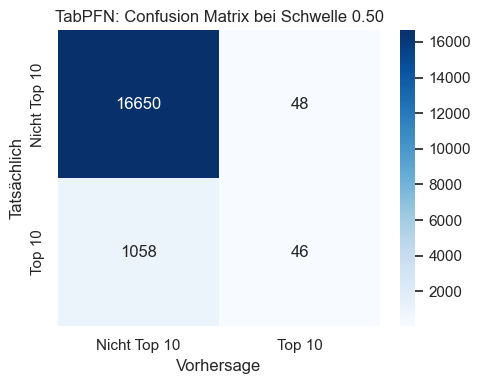

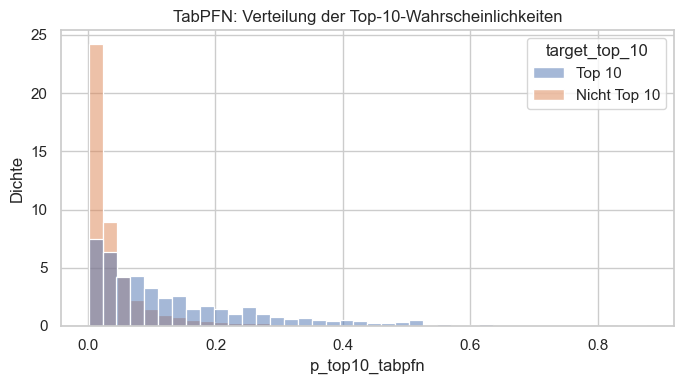

In [10]:
cm = confusion_matrix(y_test, pred_top10_050)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Nicht Top 10", "Top 10"],
    yticklabels=["Nicht Top 10", "Top 10"],
)
plt.title("TabPFN: Confusion Matrix bei Schwelle 0.50")
plt.xlabel("Vorhersage")
plt.ylabel("Tatsächlich")
plt.tight_layout()
plt.savefig(CHART_DIR / "10-02_tabpfn_confusion_matrix_top10.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(x=p_top10, hue=y_test.map({0: "Nicht Top 10", 1: "Top 10"}), bins=40, stat="density", common_norm=False)
plt.title("TabPFN: Verteilung der Top-10-Wahrscheinlichkeiten")
plt.xlabel("p_top10_tabpfn")
plt.ylabel("Dichte")
plt.tight_layout()
plt.savefig(CHART_DIR / "10-02_tabpfn_probability_distribution_top10.png", dpi=300)
plt.show()

## Von Fahrer-Wahrscheinlichkeiten zu Etappen-Prognosen

Für die fachliche Interpretation sortieren wir je Etappe alle Fahrer nach `p_top10_tabpfn`. Die Top 10 dieser Sortierung sind unsere vorhergesagten Top-10-Kandidaten für die jeweilige Etappe.

In [11]:
predictions_2024 = meta_test.reset_index(drop=True).copy()
predictions_2024["actual_rank"] = y_rank_test.reset_index(drop=True).astype(float)
predictions_2024["actual_top10"] = y_test.reset_index(drop=True).astype(int)
predictions_2024["p_top10_tabpfn"] = p_top10
predictions_2024["pred_top10_0_50"] = pred_top10_050

predictions_2024["rank_within_stage_by_model"] = (
    predictions_2024.groupby("stage_id")["p_top10_tabpfn"]
    .rank(ascending=False, method="first")
    .astype(int)
)

stage_top10_predictions = (
    predictions_2024
    .sort_values(["stage_id", "rank_within_stage_by_model"])
    .groupby("stage_id", as_index=False)
    .head(10)
    .reset_index(drop=True)
)

display(stage_top10_predictions.head(20))

,meta_year,meta_name,meta_current_team,meta_race,stage_nr,stage_id,actual_rank,actual_top10,p_top10_tabpfn,pred_top10_0_50,rank_within_stage_by_model
0,2024,Kaden Groves,Alpecin - Deceuninck,giro-d-italia,1,giro-d-italia_2024_ST1,131.0,0,0.598313,1,1
1,2024,Danny van Poppel,Red Bull - BORA - hansgrohe,giro-d-italia,1,giro-d-italia_2024_ST1,159.0,0,0.332904,0,2
2,2024,Filippo Ganna,INEOS Grenadiers,giro-d-italia,1,giro-d-italia_2024_ST1,11.0,0,0.316317,0,3
3,2024,Tadej Pogačar,UAE Team Emirates,giro-d-italia,1,giro-d-italia_2024_ST1,3.0,1,0.293614,0,4
4,2024,Alexey Lutsenko,Astana Qazaqstan Team,giro-d-italia,1,giro-d-italia_2024_ST1,22.0,0,0.273234,0,5
5,2024,Fabio Jakobsen,Team dsm-firmenich PostNL,giro-d-italia,1,giro-d-italia_2024_ST1,156.0,0,0.259901,0,6
6,2024,Olav Kooij,Team Visma | Lease a Bike,giro-d-italia,1,giro-d-italia_2024_ST1,146.0,0,0.227396,0,7
7,2024,Caleb Ewan,Team Jayco AlUla,giro-d-italia,1,giro-d-italia_2024_ST1,165.0,0,0.222027,0,8
8,2024,Jenthe Biermans,Arkéa - B&B Hotels,giro-d-italia,1,giro-d-italia_2024_ST1,99.0,0,0.194960,0,9
9,2024,Jonathan Milan,Lidl - Trek,giro-d-italia,1,giro-d-italia_2024_ST1,139.0,0,0.173177,0,10


## Stage-weite Evaluation

Diese Kennzahlen beantworten eher die sportliche Frage: Wie viele tatsächliche Top-10-Fahrer landen in unserer vorhergesagten Top 10 je Etappe? Und wie oft ist der echte Sieger unter unseren zehn Kandidaten?

In [12]:
actual_top10_per_stage = predictions_2024.groupby("stage_id")["actual_top10"].sum().rename("actual_top10_count")

stage_eval = (
    stage_top10_predictions.groupby("stage_id")
    .agg(
        actual_top10_in_predicted_top10=("actual_top10", "sum"),
        winner_in_predicted_top10=("actual_rank", lambda s: bool((s == 1).any())),
    )
    .join(actual_top10_per_stage)
    .reset_index()
)

stage_eval["stage_top10_recall"] = (
    stage_eval["actual_top10_in_predicted_top10"] / stage_eval["actual_top10_count"].replace(0, np.nan)
)

metrics.update({
    "mean_stage_top10_recall": stage_eval["stage_top10_recall"].mean(),
    "winner_hit_rate_in_predicted_top10": stage_eval["winner_in_predicted_top10"].mean(),
    "n_stages": stage_eval["stage_id"].nunique(),
})

display(stage_eval.sort_values("stage_top10_recall", ascending=False).head(10))
display(pd.DataFrame([metrics]).T.rename(columns={0: "Wert"}))

,stage_id,actual_top10_in_predicted_top10,winner_in_predicted_top10,actual_top10_count,stage_top10_recall
52,tour-de-france_2024_ST4,7,True,10,0.7
40,tour-de-france_2024_ST11,7,True,10,0.7
43,tour-de-france_2024_ST14,6,True,10,0.6
85,vuelta-a-espana_2024_ST19,6,True,10,0.6
50,tour-de-france_2024_ST20,6,True,10,0.6
104,vuelta-a-espana_2025_ST2,6,True,10,0.6
81,vuelta-a-espana_2024_ST15,5,False,10,0.5
48,tour-de-france_2024_ST19,5,True,10,0.5
8,giro-d-italia_2024_ST18,5,True,10,0.5
44,tour-de-france_2024_ST15,5,True,10,0.5


,Wert
target,target_top_10
device,mps
train_rows_used,10000
test_rows,17802
roc_auc,0.780963
average_precision,0.226363
precision_at_0_50,0.489362
recall_at_0_50,0.041667
fit_seconds,0.535585
predict_seconds,7351.073606


## Ergebnisse speichern

Das Notebook erzeugt drei Ergebnisdateien:

- `tabpfn_top10_predictions_2024.csv`: alle Testzeilen mit Metadaten, tatsächlichem Rang und Wahrscheinlichkeit.
- `tabpfn_stage_top10_predictions_2024.csv`: je Etappe die zehn Fahrer mit der höchsten TabPFN-Top-10-Wahrscheinlichkeit.
- `tabpfn_top10_metrics.csv`: globale und stage-weite Kennzahlen.

Die Dateien werden in `data/processed` gespeichert, weil sie direkt aus dem Modelllauf entstehen.

In [13]:
predictions_path = DATA_DIR / "tabpfn_top10_predictions_2024.csv"
stage_predictions_path = DATA_DIR / "tabpfn_stage_top10_predictions_2024.csv"
metrics_path = DATA_DIR / "tabpfn_top10_metrics.csv"

predictions_2024.to_csv(predictions_path, index=False)
stage_top10_predictions.to_csv(stage_predictions_path, index=False)
pd.DataFrame([metrics]).to_csv(metrics_path, index=False)

print(f"Gespeichert: {predictions_path}")
print(f"Gespeichert: {stage_predictions_path}")
print(f"Gespeichert: {metrics_path}")

Gespeichert: ../../data/processed/tabpfn_top10_predictions_2024.csv
Gespeichert: ../../data/processed/tabpfn_stage_top10_predictions_2024.csv
Gespeichert: ../../data/processed/tabpfn_top10_metrics.csv
